In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
injections = pd.read_csv('injections.dat', delimiter='\t')
injections.head()

,simulation_id,longitude,latitude,inclination,distance,mass1,mass2,spin1z,spin2z
0,0,5.923145,1.053362,2.030131,263.14581,1.267186,1.365921,-0.002450,0.015991
1,1,1.666149,-0.917026,2.639042,1282.28210,1.849061,1.636222,0.008927,0.011030
2,2,1.652701,-0.550674,2.094593,909.13148,1.610441,1.560871,0.032292,-0.041413
3,3,0.749135,1.098473,0.960501,1290.15900,1.548652,1.590885,0.024310,0.045306
4,4,3.622934,0.585640,2.643234,349.08993,1.415086,1.406627,-0.040100,0.034306


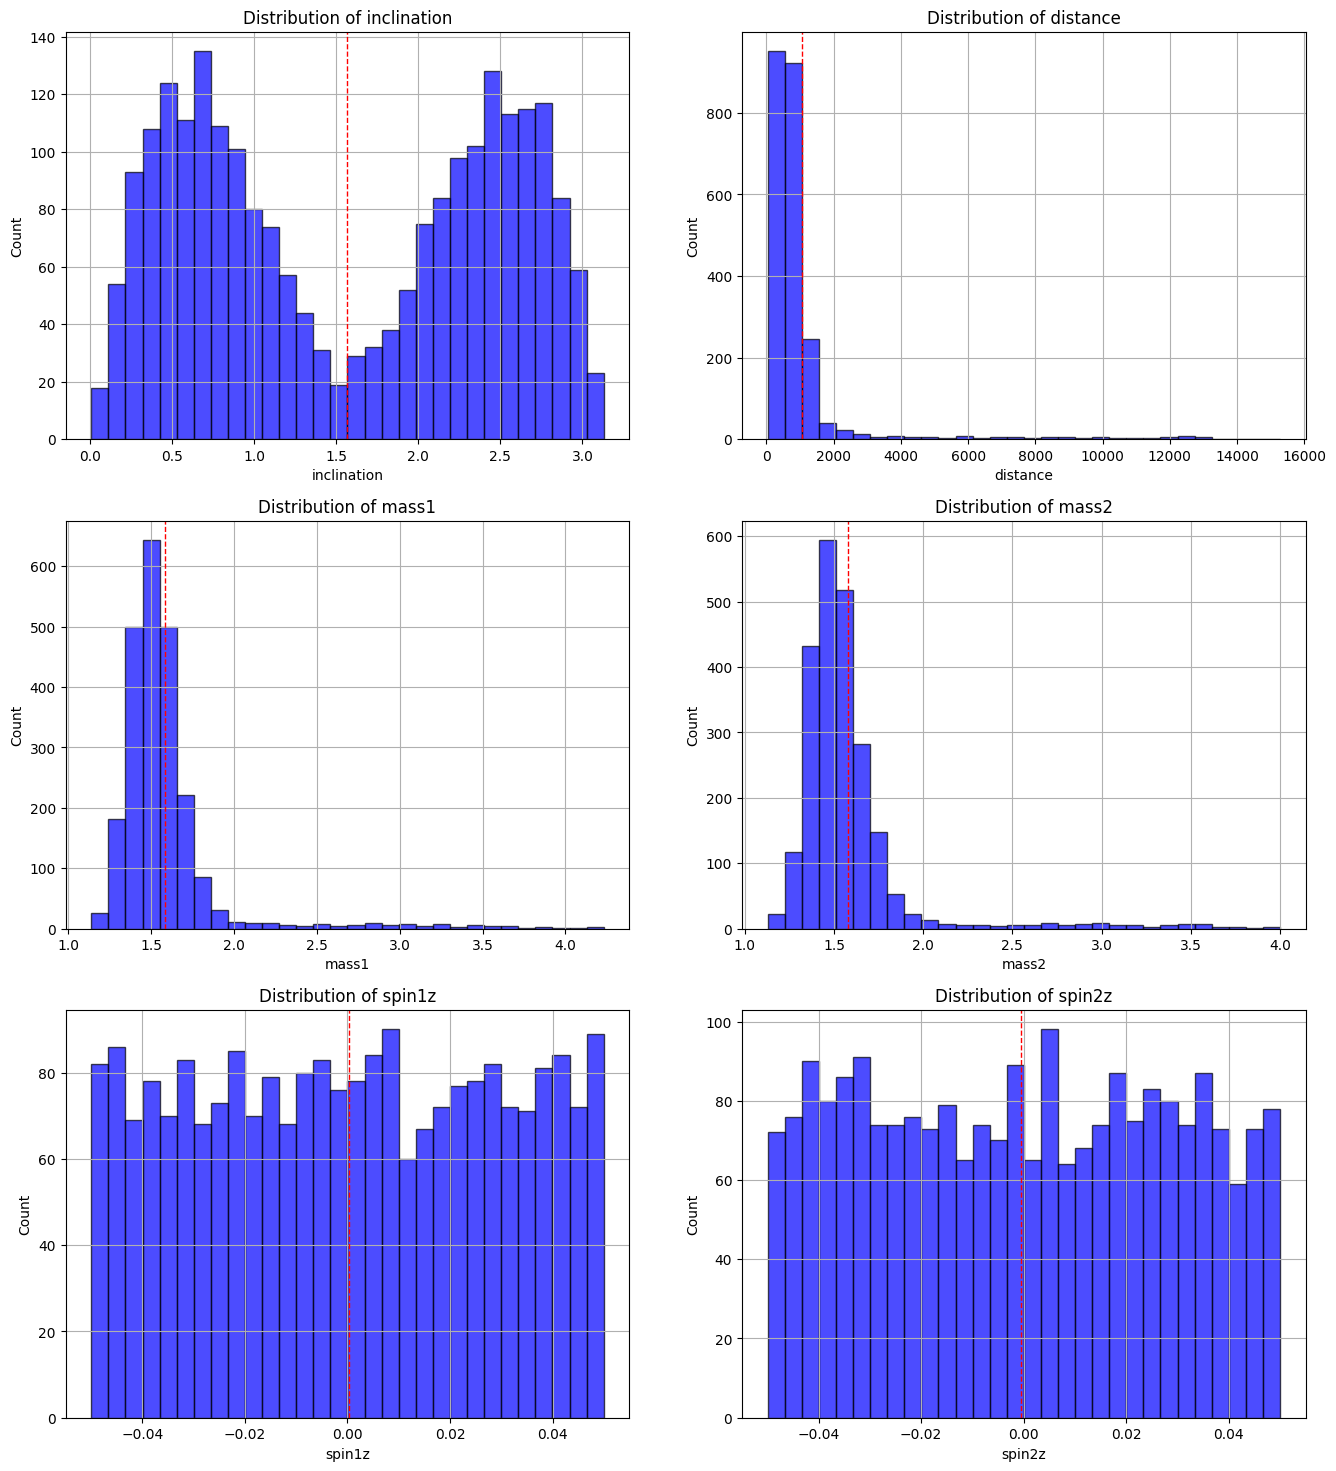

In [20]:
plt.figure(figsize=(16,18))
parameter_names = ['inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z']

for i, param in enumerate(parameter_names):
    plt.subplot(3, 2, i+1)
    plt.hist(injections[param], bins=30, alpha=0.7, color='blue', edgecolor='black')
    mean = injections[param].mean()
    std = injections[param].std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1)
    # plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1)
    # plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Count')
    plt.grid()
plt.show()

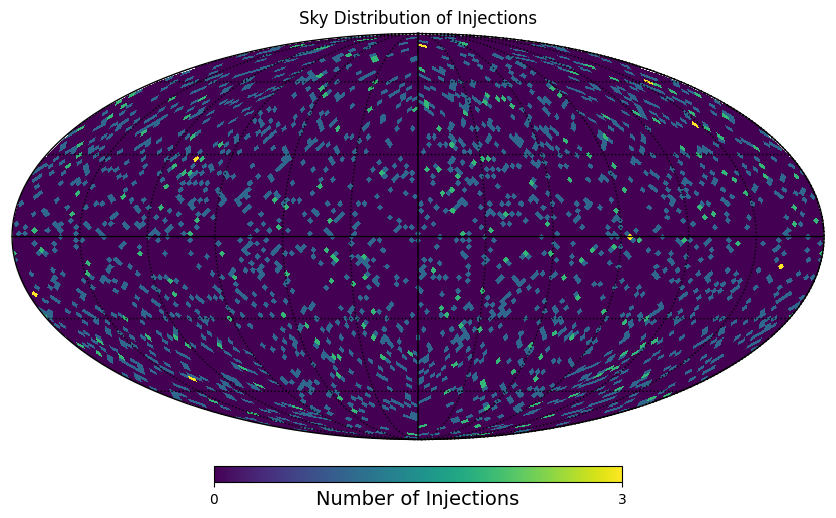

In [21]:
import healpy as hp
theta = injections['latitude'].values + np.pi/2
phi = injections['longitude'].values

nside = 32
npix = hp.nside2npix(nside)
sky_map = np.zeros(npix)
pixels = hp.ang2pix(nside, theta, phi)
for pix in pixels:
    sky_map[pix] += 1
hp.mollview(sky_map, title='Sky Distribution of Injections', unit='Number of Injections')
hp.graticule()

In [22]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import numpy as np

import astropy.units as u

def z_to_comoving_volume(z, cosmology=cosmo):
    """
    将红移 z（标量或数组）转换为共动体积（返回 astropy Quantity，单位 Mpc^3）。
    """
    return cosmology.comoving_volume(z)

def comoving_volume_to_z(V, cosmology=cosmo, z_max=20.0, ngrid=20000):
    """
    将共动体积 V 转回红移。
    - V 可以是带单位的 astropy Quantity（例如 1e9 * u.Mpc**3）或裸浮点（视为 Mpc^3）。
    - 对标量使用 astropy.cosmology.z_at_value 精确反演；对数组使用在 [0, z_max] 上的插值近似反演。
    - 返回标量或 numpy 数组（与输入形状一致）。
    """
    # 规范为 Quantity（单位 Mpc^3）
    if not hasattr(V, 'unit'):
        V = V * u.Mpc**3
    else:
        V = V.to(u.Mpc**3)

    # 标量情况：用 z_at_value
    if np.ndim(V.value) == 0:
        return z_at_value(cosmology.comoving_volume, V)

    # 数组情况：在 z 网格上计算共动体积并插值
    z_grid = np.linspace(0.0, z_max, ngrid)
    V_grid = cosmology.comoving_volume(z_grid).to(u.Mpc**3).value
    V_vals = np.asarray(V.value)
    z_vals = np.interp(V_vals, V_grid, z_grid, left=np.nan, right=np.nan)
    return z_vals

# 示例
z_example = np.array([0.10, 0.5, 1.0, 2.0])
V_example = z_to_comoving_volume(z_example)
print("z -> V (Mpc^3):", V_example)
print("V -> z (invert):", comoving_volume_to_z(V_example))

z -> V (Mpc^3): [3.39035239e+08 3.08884440e+10 1.64002856e+11 6.26509577e+11] Mpc3


V -> z (invert): [0.09999995 0.49999997 0.99999998 2.        ]


In [23]:
allsky = pd.read_csv('allsky.dat',delimiter='\t')
allsky.sort_values('coinc_event_id', inplace=True)
allsky.head()

,coinc_event_id,simulation_id,far,snr,searched_area,searched_prob,searched_prob_dist,searched_vol,searched_prob_vol,offset,...,log_bsn,area(20),area(50),area(90),dist(20),dist(50),dist(90),vol(20),vol(50),vol(90)
0,0,0,0.0,9.222875,7.042198,0.065390,0.051186,4.397681e+05,0.149232,22.596825,...,5.496516,33.290103,161.135041,1497.168572,96.495759,257.885378,648.801604,7.363696e+05,4.996358e+06,7.995625e+07
1,1,1,0.0,9.466325,49.833060,0.070082,0.926827,7.631633e+07,0.564169,49.767441,...,10.397238,187.004667,688.750814,2291.488532,153.627544,402.984777,931.300057,1.282668e+07,6.053769e+07,2.609382e+08
2,2,2,0.0,8.356897,4.688242,0.187579,0.291079,2.338952e+05,0.098888,0.938101,...,-0.669950,5.098240,29.067038,2624.458965,159.146358,423.722219,1030.870806,6.182770e+05,5.202800e+06,6.794999e+08
3,3,3,0.0,8.368183,9.284686,0.013963,0.810460,2.098307e+07,0.187184,5.132799,...,3.044212,184.728995,676.618400,2643.254877,164.200287,435.928102,1043.264222,2.298479e+07,9.686213e+07,4.677019e+08
4,4,4,0.0,13.151551,11.271451,0.256365,0.544538,3.656754e+04,0.161173,1.451152,...,34.273920,8.382112,26.964803,89.532476,41.190894,109.670954,267.527262,4.821661e+04,1.808077e+05,8.687905e+05


In [24]:
coincs = pd.read_csv('coincs.dat', delimiter='\t')
coincs.head()

,coinc_event_id,ifos,snr
0,0,"H1,K1,V1",9.222875
1,1,"H1,K1,L1",9.466325
2,2,"H1,K1,L1,V1",8.356897
3,3,"H1,K1,L1",8.368183
4,4,"K1,L1,V1",13.151551


绘制定位天区以及距离在injection以及skymap结果中的差别：部分低信噪比事件会导致距离定位偏差极大

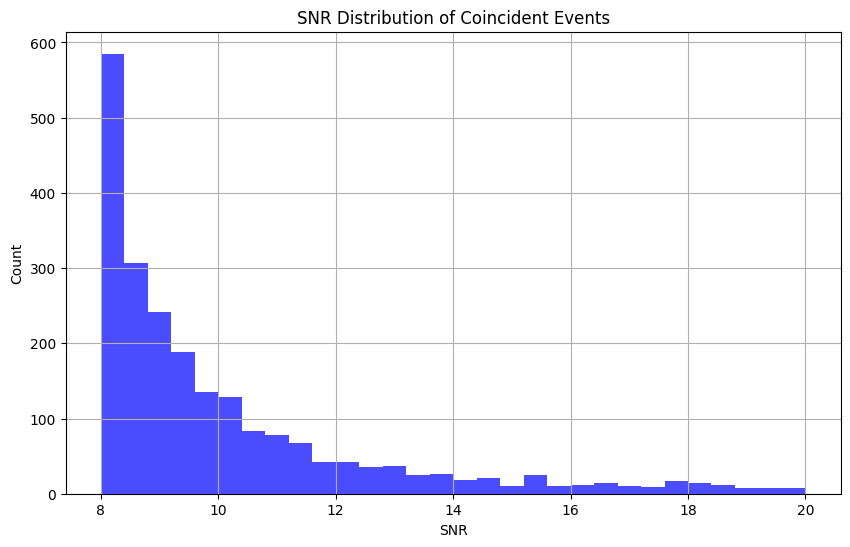

In [25]:
plt.figure(figsize=(10,6))
plt.hist(allsky['snr'].values, range=[8,20], bins=30, alpha=0.7, color='b')
plt.title('SNR Distribution of Coincident Events')
plt.xlabel('SNR')
plt.ylabel('Count')
plt.grid()
plt.show()

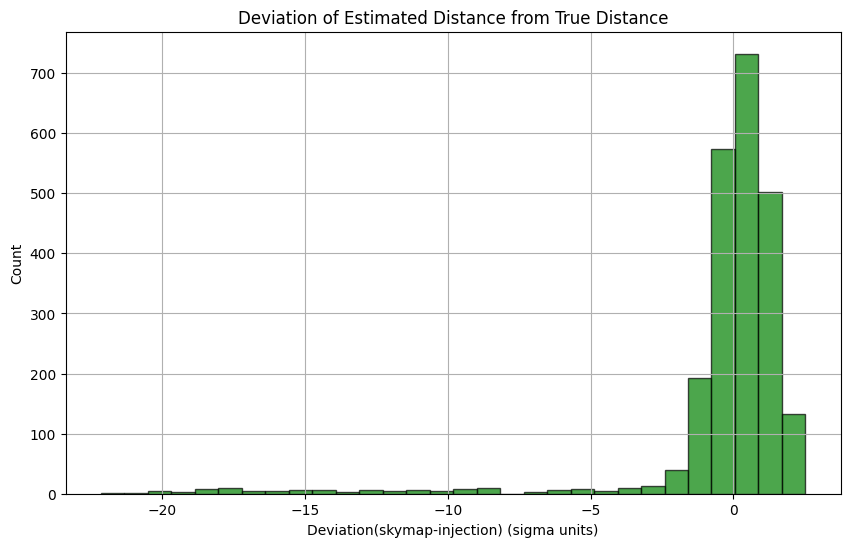

In [26]:
inj_dist = injections['distance'].values
allsky_dist = allsky['distmean'].values
allsky_diststd = allsky['diststd'].values
deviation = (allsky_dist - inj_dist) / allsky_diststd
plt.figure(figsize=(10,6))
plt.hist(deviation, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Deviation of Estimated Distance from True Distance')
plt.xlabel('Deviation(skymap-injection) (sigma units)')
plt.ylabel('Count')
plt.grid()

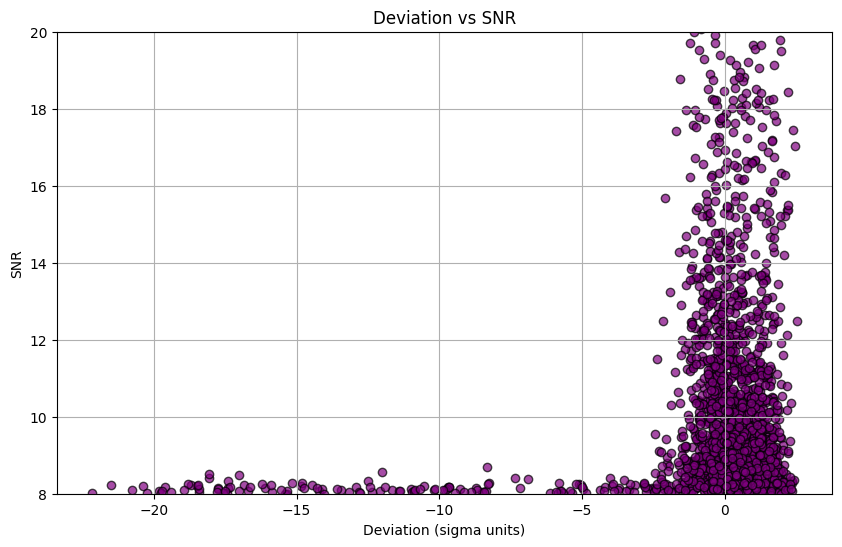

In [27]:
snr = allsky['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(deviation, snr, alpha=0.7, color='purple', edgecolor='black')
plt.title('Deviation vs SNR')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

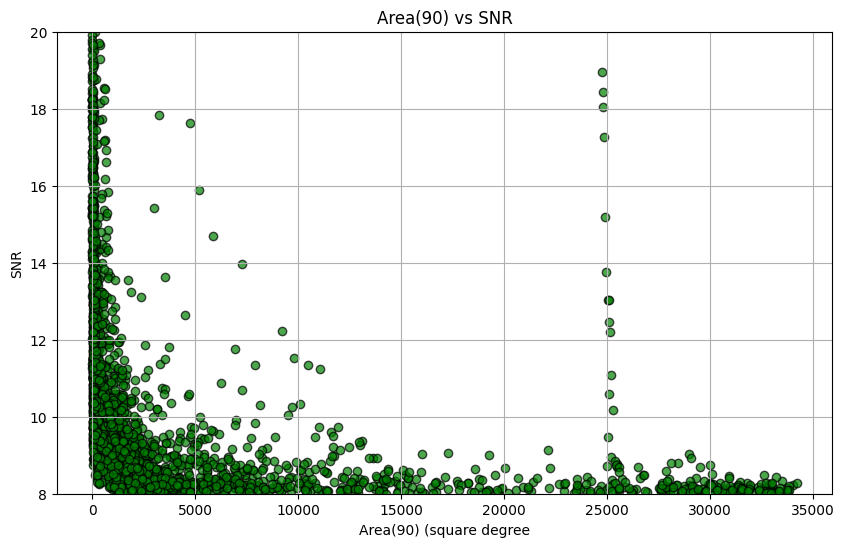

In [28]:
# plot area(90) vs snr
area90 = allsky['area(90)'].values
snr = allsky['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(area90, snr, alpha=0.7, color='g', edgecolor='black')
plt.title('Area(90) vs SNR')
plt.xlabel('Area(90) (square degree')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

injection中距离包含过多极远的事件，进行裁剪，保留小于1000Mpc的injection

In [29]:
index = np.where(injections['distance'].values < 1000)[0]
# index = np.where(np.abs(deviation)<=3)[0]
print(f"Number of injections before cut: {len(injections)}")
print(f"Number of injections after cut: {len(index)}")
injections1 = injections.iloc[index]
coincs1 = coincs.iloc[index]
allsky1 = allsky.iloc[index]

Number of injections before cut: 2307
Number of injections after cut: 1822


In [30]:
injections1.reset_index(drop=True, inplace=True)
coincs1.reset_index(drop=True, inplace=True)
allsky1.reset_index(drop=True, inplace=True)
injections1.to_csv('injections_cleaned.csv', sep=',', index=False)
coincs1.to_csv('coincs_cleaned.csv', sep=',', index=False)  
allsky1.to_csv('allsky_cleaned.csv', sep=',', index=False)

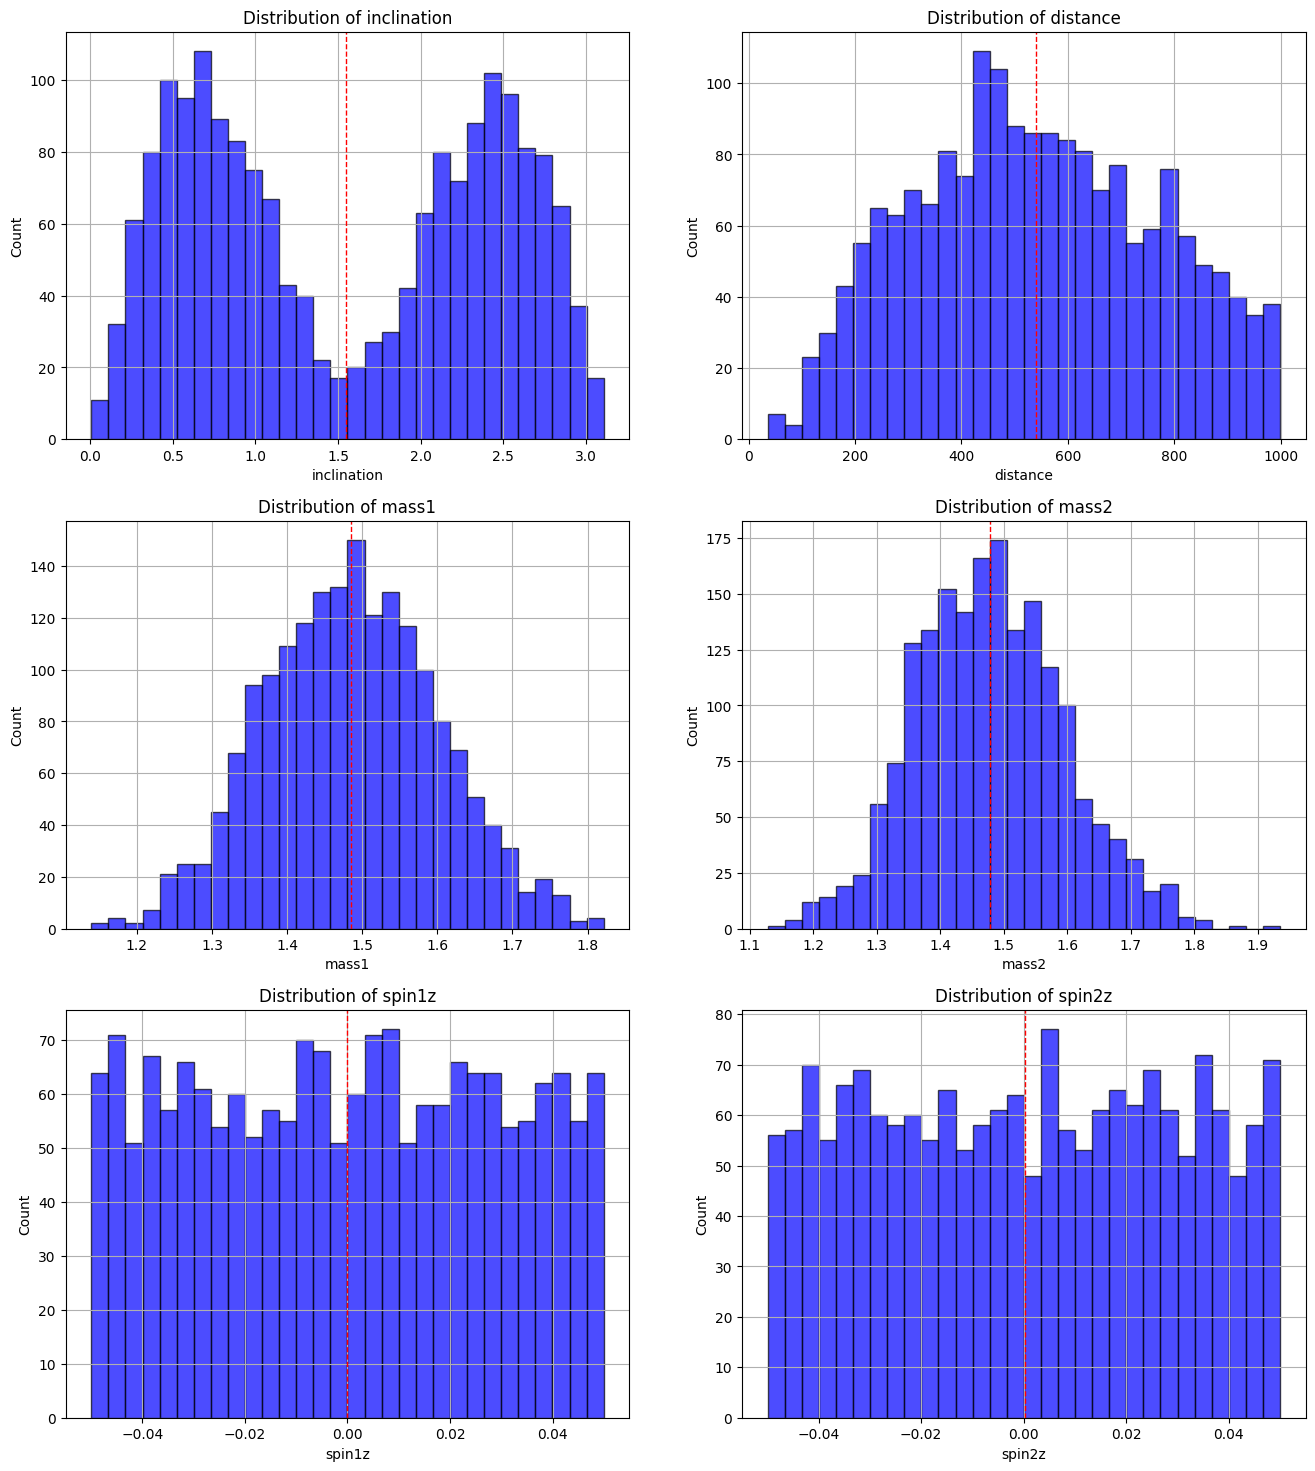

In [31]:
plt.figure(figsize=(16,18))
parameter_names = ['inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z']

for i, param in enumerate(parameter_names):
    plt.subplot(3, 2, i+1)
    plt.hist(injections1[param], bins=30, alpha=0.7, color='blue', edgecolor='black')
    mean = injections1[param].mean()
    std = injections1[param].std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1)
    # plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1)
    # plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Count')
    plt.grid()
plt.show()

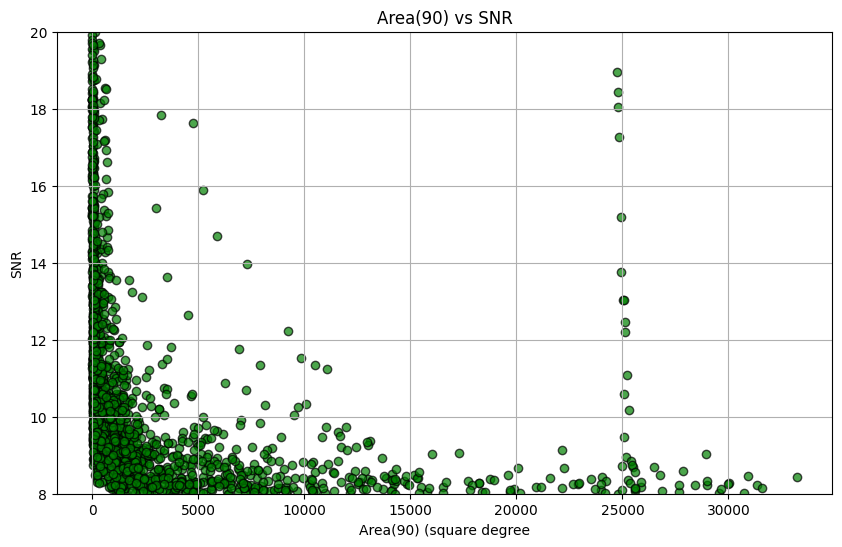

In [32]:
# plot area(90) vs snr
area901 = allsky1['area(90)'].values
snr1 = allsky1['snr'].values
plt.figure(figsize=(10,6))
plt.scatter(area901, snr1, alpha=0.7, color='g', edgecolor='black')
plt.title('Area(90) vs SNR')
plt.xlabel('Area(90) (square degree')
plt.ylabel('SNR')
plt.ylim((8,20))
plt.grid()

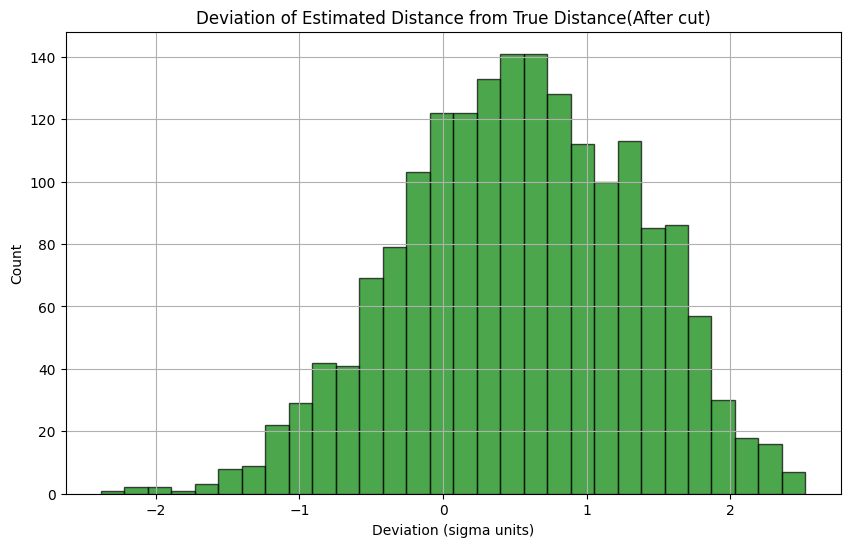

In [33]:
inj1_dist = injections1['distance'].values
allsky1_dist = allsky1['distmean'].values
allsky1_diststd = allsky1['diststd'].values
deviation1 = (allsky1_dist - inj1_dist) / allsky1_diststd
plt.figure(figsize=(10,6))
plt.hist(deviation1, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.title('Deviation of Estimated Distance from True Distance(After cut)')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('Count')
plt.grid()

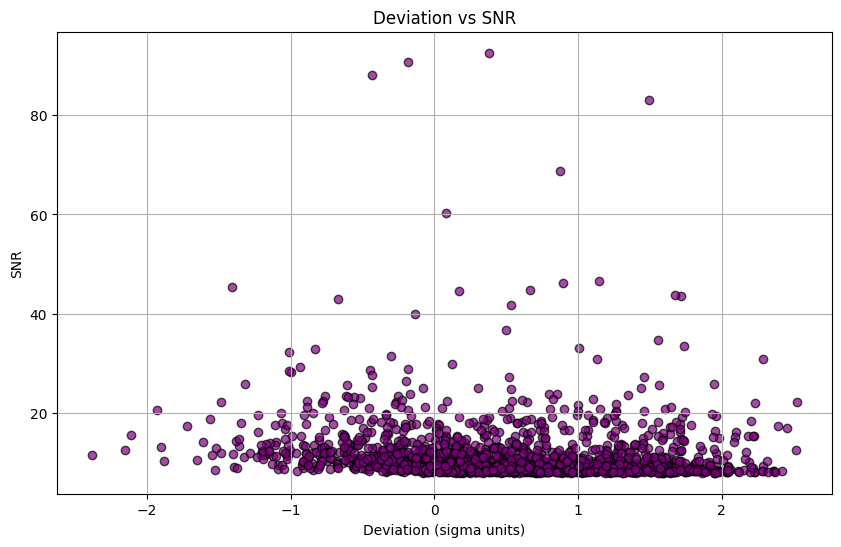

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(deviation1, snr1, alpha=0.7, color='purple', edgecolor='black')
plt.title('Deviation vs SNR')
plt.xlabel('Deviation (sigma units)')
plt.ylabel('SNR')
# plt.ylim((8,20))
plt.grid()